Total Connected Components: 111


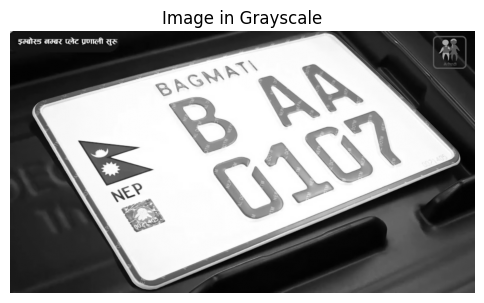

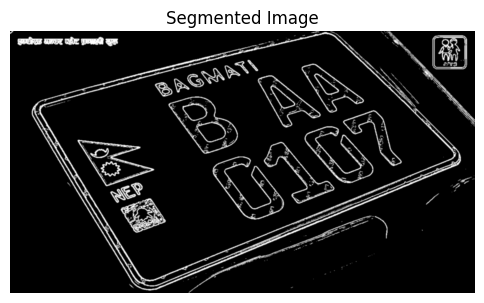

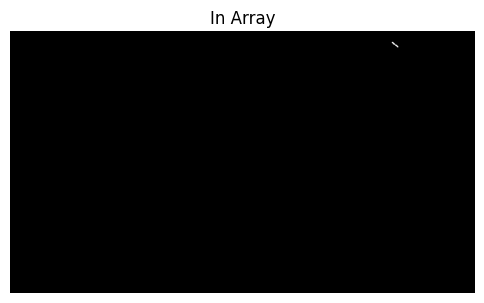

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.measure import label

# Read image
im = cv2.imread("number_plate.jpg")

# Convert BGR to RGB (for displaying)
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Convert to grayscale
im1 = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Median filtering (3x3)
im1 = cv2.medianBlur(im1, 3)

# Sobel edge detection
grad_x = cv2.Sobel(im1, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(im1, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(grad_x**2 + grad_y**2)
BW = (magnitude > 100).astype(np.uint8)   # Threshold can be adjusted

# Image dimensions
imx, imy = BW.shape

# Mask (same as MATLAB)
msk = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=np.uint8)

# Convolution
B = convolve2d(BW.astype(float), msk.astype(float), mode='same')

# Connected component labeling (8-connectivity)
L = label(B > 0, connectivity=2)

mx = L.max()
print("Total Connected Components:", mx)

# MATLAB extracts component 17
component_number = 17

n1 = np.zeros((imx, imy), dtype=np.uint8)

if component_number <= mx:
    r, c = np.where(L == component_number)
    n1[r, c] = 255
else:
    print(f"Component {component_number} not found.")

# Display results
plt.figure(figsize=(6,6))
plt.imshow(im1, cmap='gray')
plt.title("Image in Grayscale")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(B, cmap='gray')
plt.title("Segmented Image")
plt.axis("off")

plt.figure(figsize=(6,6))
plt.imshow(n1, cmap='gray')
plt.title("In Array")
plt.axis("off")

plt.show()

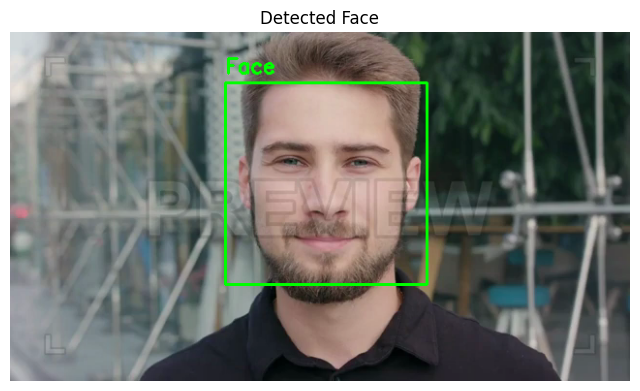

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load Haar Cascade face detector
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open the video file
video = cv2.VideoCapture("video.mp4")

# Read the first frame
ret, frame = video.read()

if not ret:
    print("Error: Could not read the video.")
    exit()

# Convert frame to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# Draw rectangles around detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(frame, "Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (0, 255, 0), 2)

# Convert BGR to RGB for Matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("Detected Face")
plt.axis("off")
plt.show()

# Release the video
video.release()

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the image relative to the notebook location
image_path = None
for candidate in [
    Path.cwd() / "home.jpg",
    Path.cwd().parent / "lab6" / "home.jpg",
    Path("/Users/mrs/IPPR lab/lab6/home.jpg"),
]:
    if candidate.exists():
        image_path = candidate
        break

if image_path is None:
    raise FileNotFoundError("Could not find home.jpg. Make sure it is in the same folder as this notebook.")

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

if image is None or image.size == 0:
    raise ValueError(f"Failed to load image from {image_path}")

if image.dtype != np.uint8:
    image = image.astype(np.uint8)

print("Loaded image:", image_path)
print("Shape:", image.shape, "dtype:", image.dtype)


Loaded image: /Users/mrs/IPPR lab/lab6/home.jpg
Shape: (384, 512) dtype: uint8


In [8]:
# Detecting Keypoints
siftObj = cv2.SIFT_create()
keyPoints, descriptors = siftObj.detectAndCompute(image, None)

print("Number of keypoints:", len(keyPoints))
print("Descriptor shape:", None if descriptors is None else descriptors.shape)


Number of keypoints: 881
Descriptor shape: (881, 128)


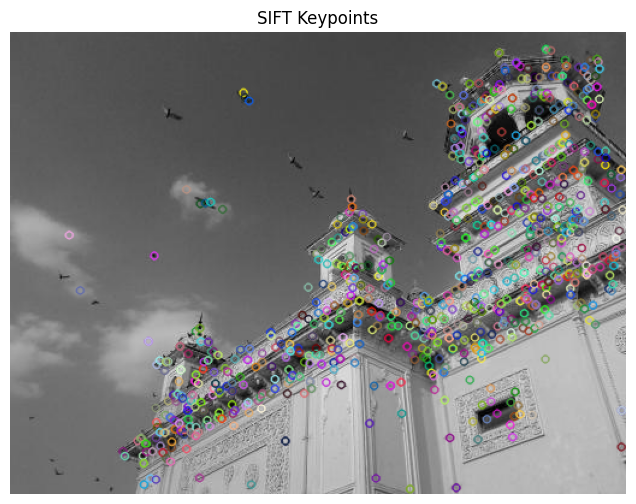

In [10]:
# Drawing Keypoints on Input Image
result = cv2.drawKeypoints(image, keyPoints, None)

plt.figure(figsize=(8, 6))
plt.imshow(result, cmap='gray')
plt.title('SIFT Keypoints')
plt.axis('off')
plt.show()


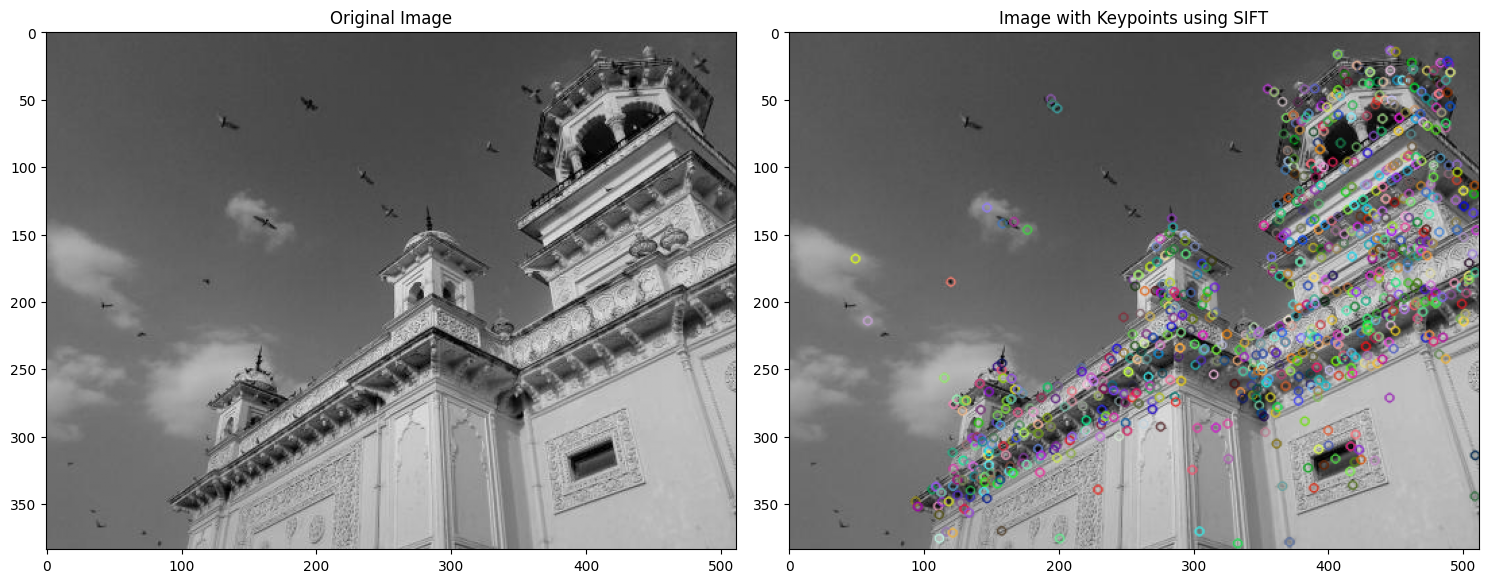

In [11]:
# Displaying Results
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

try:
    sift_obj = cv2.SIFT_create()
    keypoints, _ = sift_obj.detectAndCompute(image, None)
    result = cv2.drawKeypoints(image, keypoints, None)
except Exception as e:
    print("SIFT visualization fallback due to:", e)
    result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image')
ax2.imshow(result)
ax2.set_title('Image with Keypoints using SIFT')

plt.tight_layout()
plt.show()
